# 01 · Diagnosi: radar del Meteocat vs estacions XEMA

Abans de calibrar res, aquest notebook respon tres preguntes:

1. **El "dia" de la XEMA i el del radar són la mateixa franja horària?** Si no ho fossin, part de l'error seria un desfasament i no un error del radar.
2. **Hi ha estacions o dies amb dades dolentes** que convingui excloure de la calibració?
3. **Quin error té el producte actual** (taula de colors manual de `radar_to_nc.py`) i de quin tipus és?

**Dades** (generades pel pipeline, carpeta `validacio/`):
- `parelles/`: per a cada estació i dia, la pluja XEMA i l'acumulat diari del radar al píxel de l'estació.
- `recomptes/`: per a cada estació i dia, quantes imatges de 6 min ha tingut el píxel de cada color.
- `analisi/dades/radar_horari_estacions.csv.gz`: acumulat horari del radar al píxel de cada estació (extret de l'historial de git amb `eines/extreure_horari.py`).

Període: del **5 de març** (data des de la qual la taula de colors és l'actual) al **2 d'octubre de 2026**, amb 187 estacions.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import calibracio as C
C.estil()
pd.set_option('display.precision', 2); pd.set_option('display.width', 200)

In [2]:
df = C.carregar()
print(f"{len(df):,} estació-dies · {df.codi.nunique()} estacions · {df.data.nunique()} dies "
      f"({df.data.min():%d/%m/%Y} – {df.data.max():%d/%m/%Y})")
print(f"Estació-dies amb pluja (≥1 mm a l'estació): {(df.obs >= 1).sum():,}")

39,348 estació-dies · 187 estacions · 212 dies (05/03/2026 – 02/10/2026)
Estació-dies amb pluja (≥1 mm a l'estació): 5,058


## 1. Quina franja horària és el "dia" de la XEMA?

Construïm l'acumulat diari del radar desplaçant la finestra de 24 h entre −12 i +12 hores respecte de 00–24 UTC, i mirem amb quin desplaçament s'assembla més a la pluja diària de la XEMA. Si la XEMA fes servir, per exemple, el dia pluviomètric de 07 a 07, el màxim sortiria a +7 h.

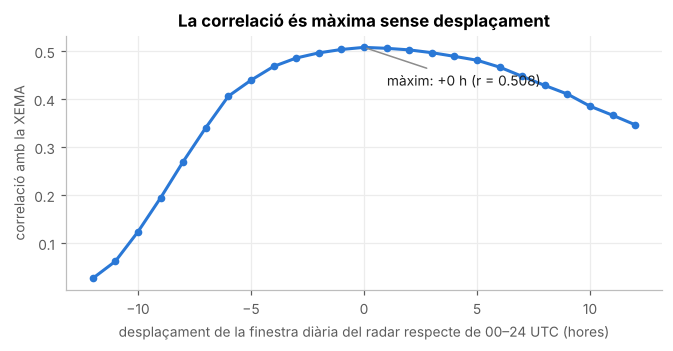

In [3]:
h = pd.read_csv('dades/radar_horari_estacions.csv.gz', parse_dates=['hora_utc'])
obs = df[['data', 'codi', 'obs']]
res = []
for s in range(-12, 13):
    d = h.assign(data=(h.hora_utc - pd.Timedelta(hours=s)).dt.floor('D'))
    r = d.groupby(['data', 'codi']).radar_mm.sum().rename('r').reset_index()
    m = obs.merge(r, on=['data', 'codi'], how='left').fillna({'r': 0})
    m = m[(m.data > df.data.min()) & (m.data < df.data.max())]   # evitem les vores
    w = m[(m.obs >= 1) | (m.r >= 1)]
    res.append((s, np.corrcoef(w.r, w.obs)[0, 1]))
res = pd.DataFrame(res, columns=['desplaçament_h', 'correlacio'])

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(res['desplaçament_h'], res.correlacio, color=C.COLORS['blau'], marker='o', ms=4)
best = res.loc[res.correlacio.idxmax()]
ax.annotate(f"màxim: {best['desplaçament_h']:+.0f} h (r = {best.correlacio:.3f})",
            (best['desplaçament_h'], best.correlacio), xytext=(15, -25), textcoords='offset points',
            color=C.COLORS['tinta'], arrowprops=dict(arrowstyle='-', color=C.COLORS['gris']))
ax.set_xlabel("desplaçament de la finestra diària del radar respecte de 00–24 UTC (hores)")
ax.set_ylabel("correlació amb la XEMA")
ax.set_title("La correlació és màxima sense desplaçament")
plt.show()

**Resultat:** la correlació és màxima amb desplaçament 0. El dia de la XEMA (estadístic diari de la variable 1300) correspon a **00–24 UTC**, igual que el del radar. No hi ha cap desfasament horari que corregir.

## 2. Control de qualitat de les estacions

Comparem cada estació amb la mediana de les estacions veïnes (dins de 20 km) i amb el radar al seu píxel. Marquem com a sospitosos:
- **zero sospitós:** l'estació marca 0 mm però els veïns i el radar marquen ≥5 mm (possible pluviòmetre obstruït);
- **extrem sospitós:** l'estació marca >30 mm i més de 5 vegades els veïns i el radar.

No vol dir que siguin errors segurs (una tempesta pot ser molt local), però per calibrar és més prudent deixar-los fora.

In [4]:
df = C.control_qualitat(df)
print(df.qc_flag.replace('', 'correcte').value_counts().to_string())
df.loc[~df.qc_ok, ['data', 'codi', 'nom', 'obs', 'mediana_veins', 'radar_px', 'qc_flag']].sort_values('data')

qc_flag
correcte           39332
extrem_sospitos       14
zero_sospitos          2


,data,codi,nom,obs,mediana_veins,radar_px,qc_flag
10891,2026-05-02,YF,Miami Platja,40.3,7.00,1.94,extrem_sospitos
13723,2026-05-18,D5,Barcelona - Observatori Fabra,33.9,3.15,2.55,extrem_sospitos
13869,2026-05-18,YO,Sant Sadurní d'Anoia,38.6,5.40,6.44,extrem_sospitos
17091,2026-06-05,US,les Cases d'Alcanar,61.1,0.50,0.10,extrem_sospitos
19231,2026-06-16,Z3,Malniu (2.229 m),40.9,2.20,5.88,extrem_sospitos
21503,2026-06-29,KP,Fogars de la Selva,0.0,35.40,8.20,zero_sospitos
28643,2026-08-06,WQ,Montsec d'Ares (1.571 m),78.7,4.70,4.70,extrem_sospitos
31539,2026-08-22,D9,el Vendrell,129.4,12.20,19.10,extrem_sospitos
31644,2026-08-22,XE,Tarragona - Complex Educatiu,48.8,3.60,3.49,extrem_sospitos
31910,2026-08-24,D8,Horta de Sant Joan,0.0,5.55,5.24,zero_sospitos


In [5]:
# Estacions amb el total del període molt diferent dels veïns
st = C.estacions(df)
piv = df.pivot_table(index='data', columns='codi', values='obs')
tot = df.groupby('codi').agg(total=('obs', 'sum'), total_veins=('mediana_veins', 'sum'))
tot['ratio_veins'] = tot.total / tot.total_veins
print(f"Rati total estació / mediana veïns: mediana {tot.ratio_veins.median():.2f}, "
      f"5-95%: {tot.ratio_veins.quantile(.05):.2f}–{tot.ratio_veins.quantile(.95):.2f}")
tot = tot[tot.total_veins > 0]   # estacions sense prou veïns: no comparables
tot.join(st.nom).sort_values('ratio_veins').iloc[[0,1,2,-3,-2,-1]]

Rati total estació / mediana veïns: mediana 1.17, 5-95%: 0.82–1.79


,total,total_veins,ratio_veins,nom
codi,,,,
XH,277.7,434.15,0.64,Sort
W5,185.1,278.30,0.67,Oliana
DO,199.0,288.90,0.69,Castell d'Aro
Y6,313.9,152.00,2.07,Tivissa
X5,517.8,235.70,2.20,PN dels Ports
US,504.2,228.25,2.21,les Cases d'Alcanar


**Resultat:** només **16 estació-dies** de ~39.000 són sospitosos, i cap estació té un comportament anòmal persistent (no hi ha dies a zero repetits quan els veïns plouen). Els totals que difereixen dels veïns (vegeu el rang 5–95% de dalt) es poden explicar per la variabilitat real de la pluja convectiva en mig any i per l'altitud (estacions de muntanya). La qualitat de la XEMA és bona; per calibrar, excloem només aquests casos.

## 3. Error del producte actual

Comparem la pluja diària de la XEMA amb l'acumulat del radar al píxel de l'estació, sobre els estació-dies amb pluja observada (≥1 mm).

In [6]:
q = df[df.qc_ok]
C.taula_metriques(q, ['radar_px'])

,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
radar_px,5044.0,0.46,0.51,6.87,13.21,-5.57,0.95,11.1


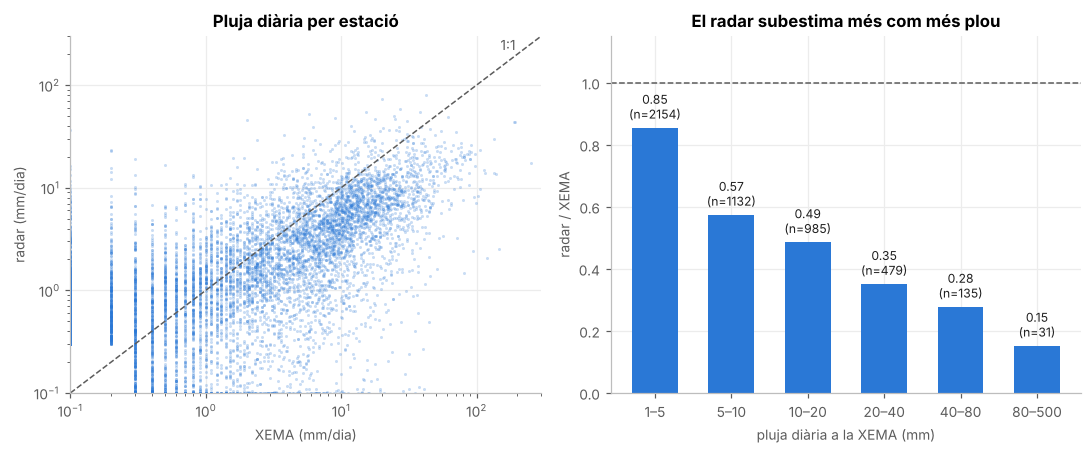

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
w = q[(q.obs >= 0.2) | (q.radar_px >= 0.2)]
ax = axs[0]
ax.scatter(w.obs + .1, w.radar_px + .1, s=4, alpha=.25, color=C.COLORS['blau'], linewidths=0)
ax.plot([.1, 300], [.1, 300], color=C.COLORS['tinta2'], lw=1, ls='--')
ax.text(150, 220, '1:1', color=C.COLORS['tinta2'])
ax.set(xscale='log', yscale='log', xlim=(.1, 300), ylim=(.1, 300),
       xlabel='XEMA (mm/dia)', ylabel='radar (mm/dia)', title='Pluja diària per estació')

bins = [1, 5, 10, 20, 40, 80, 500]
q2 = q[q.obs >= 1].assign(classe=pd.cut(q.obs, bins))
g = q2.groupby('classe', observed=True).apply(lambda x: pd.Series({'ratio': x.radar_px.sum() / x.obs.sum(), 'n': len(x)}))
ax = axs[1]
ax.bar(range(len(g)), g.ratio, color=C.COLORS['blau'], width=.6)
ax.axhline(1, color=C.COLORS['tinta2'], lw=1, ls='--')
for i, (r, n) in enumerate(zip(g.ratio, g.n)):
    ax.text(i, r + .02, f"{r:.2f}\n(n={int(n)})", ha='center', va='bottom', fontsize=8, color=C.COLORS['tinta'])
ax.set_xticks(range(len(g)), [f"{int(i.left)}–{int(i.right)}" for i in g.index])
ax.set(ylim=(0, 1.15), xlabel='pluja diària a la XEMA (mm)', ylabel='radar / XEMA',
       title='El radar subestima més com més plou')
plt.tight_layout(); plt.show()

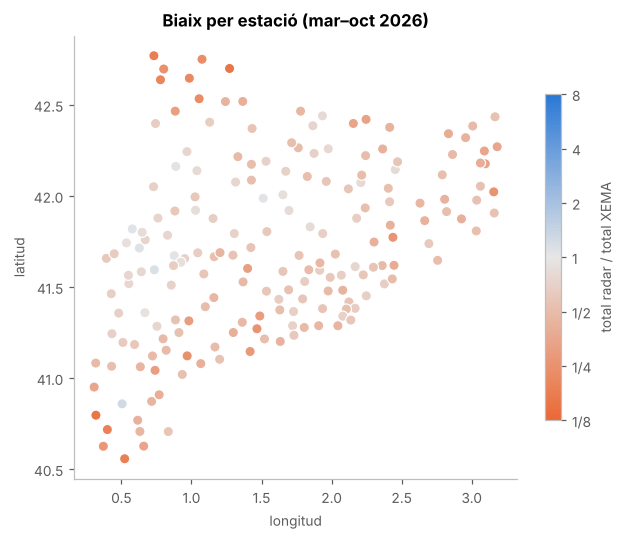

Rati radar/XEMA per estació: mediana 0.55, 10–90%: 0.31–0.79


In [8]:
# Distribució espacial del biaix: total radar / total XEMA per estació
s = q.groupby('codi').agg(o=('obs', 'sum'), r=('radar_px', 'sum')).join(st)
s['ratio'] = s.r / s.o
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(s.lon, s.lat, c=np.log2(s.ratio), cmap=C.cmap_divergent(), vmin=-3, vmax=3, s=45,
                edgecolors='white', linewidths=.8)
cb = plt.colorbar(sc, ax=ax, shrink=.7, ticks=[-3, -2, -1, 0, 1, 2, 3])
cb.ax.set_yticklabels(['1/8', '1/4', '1/2', '1', '2', '4', '8'])
cb.set_label('total radar / total XEMA')
ax.set(xlabel='longitud', ylabel='latitud', title='Biaix per estació (mar–oct 2026)')
ax.set_aspect(1.3); ax.grid(False); plt.show()
print(f"Rati radar/XEMA per estació: mediana {s.ratio.median():.2f}, 10–90%: {s.ratio.quantile(.1):.2f}–{s.ratio.quantile(.9):.2f}")

In [9]:
# Per mesos
q.assign(mes=q.data.dt.strftime('%Y-%m')).groupby('mes').apply(
    lambda x: C.metriques(x.obs, x.radar_px))[['n', 'ratio_total', 'r', 'MAE']]

,n,ratio_total,r,MAE
mes,,,,
2026-03,1057.0,0.26,0.60,10.00
2026-04,645.0,0.53,0.33,4.91
2026-05,1245.0,0.54,0.59,4.26
2026-06,373.0,0.44,0.67,6.70
2026-07,158.0,1.07,0.61,3.21
2026-08,800.0,0.73,0.49,6.52
2026-09,507.0,0.39,0.77,9.43
2026-10,259.0,0.38,0.69,10.13


## 4. Imatges que falten

L'acumulat suma 0,1 h per imatge, suposant 240 imatges/dia. Quan el cron no descarrega alguna imatge, l'acumulat queda curt.

In [10]:
im = df.groupby('data').n_imatges.first()
print(f"Imatges per dia: mediana {im.median():.0f}, mínim {im.min()}, dies amb <200: {(im < 200).sum()} de {len(im)}")
print(f"Pèrdua mitjana d'acumulat per imatges que falten: {100 * (1 - im.mean() / 240):.1f}%")

Imatges per dia: mediana 232, mínim 168, dies amb <200: 26 de 212
Pèrdua mitjana d'acumulat per imatges que falten: 6.4%


## Conclusions

| Pregunta | Resposta |
|---|---|
| Franja del dia XEMA | 00–24 UTC, la mateixa que el radar. No cal corregir res. |
| Qualitat XEMA | Bona: només 16 estació-dies sospitosos (exclosos de la calibració). |
| Biaix global | El radar dona **~la meitat** de la pluja observada. |
| Dependència amb la intensitat | Com més plou, més subestima (0,85 entre 1–5 mm, 0,15 per sobre de 80 mm). |
| Biaix espacial | Molt variable entre estacions (10–90%: 0,31–0,79): el radar subestima més al Pirineu i a les Terres de l'Ebre, i menys a la Depressió Central. |
| Falses alarmes | Molt poques: <1% dels dies secs tenen ≥1 mm de radar. |
| Imatges que falten | Pèrdua mitjana del ~6% de l'acumulat; 26 dies amb menys de 200 imatges de 240. |

**Implicacions per a la calibració:**
- La subestimació depèn de la intensitat → té sentit **reajustar la taula de colors** (notebook 02).
- La subestimació depèn molt del lloc → una sola taula no ho pot corregir tot; cal una **correcció espacial amb les estacions** (notebook 03).
- Normalitzar per les imatges descarregades és una millora petita però gratuïta.